## Zero-Shot Reference Mapping chord blood (cb) dataset

In [33]:
from pathlib import Path
import numpy as np
from scipy.stats import mode
import scanpy as sc
import warnings
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd
import sys
import scgpt as scg
import os
#sys.path.insert(0, "../")
# sys.path.insert(0, "../../")

# extra dependency for similarity search
try:
    import faiss

    faiss_imported = True
except ImportError:
    faiss_imported = False
    print(
        "faiss not installed! We highly recommend installing it for fast similarity search."
    )
    print("To install it, see https://github.com/facebookresearch/faiss/wiki/Installing-Faiss")

warnings.filterwarnings("ignore", category=ResourceWarning)

To check the directory (and to modify use %cd and other linux comands) both works

In [34]:
# %pwd
# os.getcwd()

### Read the dataset

In [35]:
model_dir = Path("/projects/shared/intronic_bam/scGPT_supplements/save/scGPT_human")
train_cb = sc.read_h5ad('/projects/shared/intronic_bam/datasets/anndata/train_sce_cb.h5ad')
test_cb = sc.read_h5ad('/projects/shared/intronic_bam/datasets/anndata/test_sce_cb.h5ad')

cell_type_key = "celltype"
gene_col = "gene_names" # name of the vector in the anndata.var with the gene names 

In [36]:
train_cb.X = train_cb.layers['counts']
test_cb.X = test_cb.layers['counts']


sc.pp.normalize_total(train_cb, target_sum=1e4)
sc.pp.log1p(train_cb)
sc.pp.normalize_total(test_cb, target_sum=1e4)
sc.pp.log1p(test_cb)

Embed the train and test dataset

In [37]:
ref_embed_adata = scg.tasks.embed_data(
    train_cb,
    model_dir,
    gene_col=gene_col,
    batch_size=64
)

test_embed_adata = scg.tasks.embed_data(
    test_cb,
    model_dir,
    gene_col=gene_col,
    batch_size=64,
)

scGPT - INFO - match 17769/20400 genes in vocabulary of size 60697.


/software/envs/micromamba/envs/nw-scGPTv2/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer was not TransformerEncoderLayer
  warnings.warn(
/software/envs/micromamba/envs/nw-scGPTv2/lib/python3.11/site-packages/scgpt/tasks/cell_emb.py:120: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=True):
Embedding cells: 100%|██████████| 86/86 [00:10<00:00,  8.31it/s]
/software/envs/micromamba/envs/nw-scGPTv2/lib/python3.11/site-packages/scgpt/tasks/cell_emb.py:279: ImplicitModificationWarning: Setting element `.obsm['X_scGPT']` of view, initializing view as actual.
  adata.obsm["X_scGPT"] = cell_embeddings


scGPT - INFO - match 17769/20400 genes in vocabulary of size 60697.


/software/envs/micromamba/envs/nw-scGPTv2/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer was not TransformerEncoderLayer
  warnings.warn(
/software/envs/micromamba/envs/nw-scGPTv2/lib/python3.11/site-packages/scgpt/tasks/cell_emb.py:120: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=True):
Embedding cells: 100%|██████████| 38/38 [00:04<00:00,  8.06it/s]
/software/envs/micromamba/envs/nw-scGPTv2/lib/python3.11/site-packages/scgpt/tasks/cell_emb.py:279: ImplicitModificationWarning: Setting element `.obsm['X_scGPT']` of view, initializing view as actual.
  adata.obsm["X_scGPT"] = cell_embeddings


In [38]:
ref_embed_adata

AnnData object with n_obs × n_vars = 5476 × 17769
    obs: 'adt.discard', 'mito.discard', 'discard', 'species', 'celltype', 'markers', 'sum', 'detected', 'subsets_Mito_sum', 'subsets_Mito_detected', 'subsets_Mito_percent', 'altexps_scADT_sum', 'altexps_scADT_detected', 'altexps_scADT_percent', 'total', 'is_train'
    var: 'gene_names', 'id_in_vocab'
    uns: 'log1p'
    obsm: 'X_scGPT'
    layers: 'counts'

In [39]:
# concatenate the two datasets
adata_concat = test_embed_adata.concatenate(ref_embed_adata, batch_key="dataset")
# mark the reference vs. query dataset
adata_concat.obs["is_ref"] = ["Query"] * len(test_embed_adata) + ["Reference"] * len(
    ref_embed_adata
)
adata_concat.obs["is_ref"] = adata_concat.obs["is_ref"].astype("category")
# mask the query dataset cell types
cell_key_masked = f"{cell_type_key}_masked"
adata_concat.obs[cell_key_masked] = adata_concat.obs[cell_type_key].astype("category")
adata_concat.obs[cell_key_masked] = adata_concat.obs[cell_key_masked].cat.add_categories(["To be predicted"])
adata_concat.obs[cell_key_masked][: len(test_embed_adata)] = "To be predicted"

/tmp/ipykernel_346023/1917710629.py:2: FutureWarning: The method concatenate is deprecated and will be removed in the future. Use anndata.concat instead of AnnData.concatenate. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_concat = test_embed_adata.concatenate(ref_embed_adata, batch_key="dataset")
/tmp/ipykernel_346023/1917710629.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single 

# Visualize the embeddings

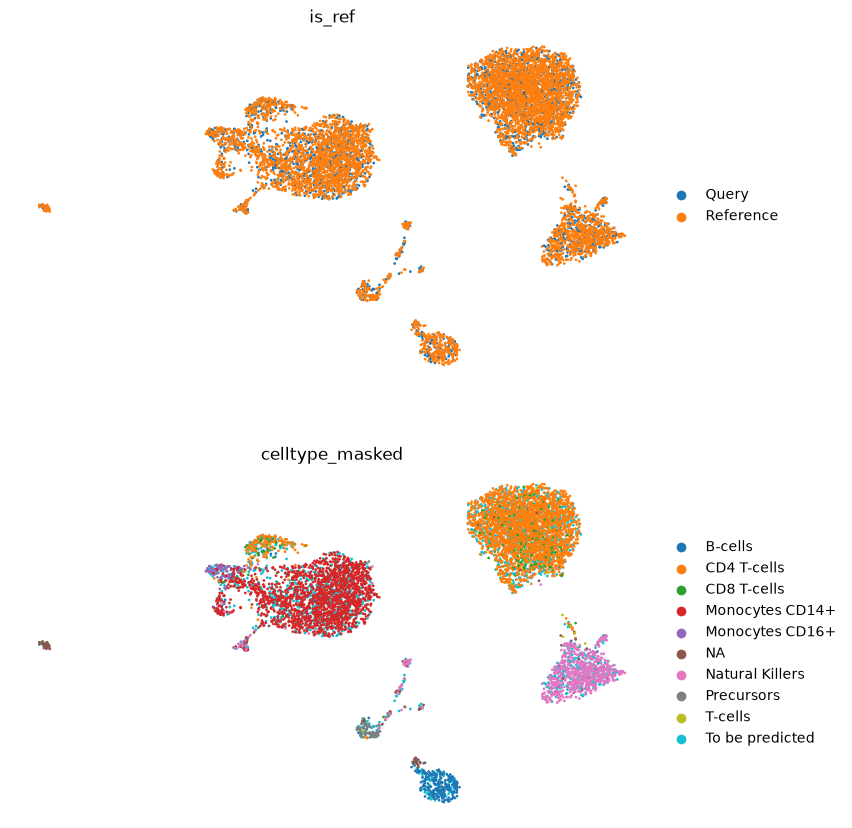

In [40]:
sc.pp.neighbors(adata_concat, use_rep="X_scGPT")
sc.tl.umap(adata_concat)
sc.pl.umap(
    adata_concat, color=["is_ref", cell_key_masked], wspace=0.4, frameon=False, ncols=1
)

# Reference mapping and transfer the annotation

Function to use when faiss is not installed

In [24]:
# Those functions are only used when faiss is not installed
def l2_sim(a, b):
    sims = -np.linalg.norm(a - b, axis=1)
    return sims

def get_similar_vectors(vector, ref, top_k=10):
        # sims = cos_sim(vector, ref)
        sims = l2_sim(vector, ref)
        
        top_k_idx = np.argsort(sims)[::-1][:top_k]
        return top_k_idx, sims[top_k_idx]

We run the reference mapping using cell-level majority voting. You may adjust the k parameter to control the number of nearest neighbors to consider for voting.

In [41]:
ref_cell_embeddings = ref_embed_adata.obsm["X_scGPT"]
test_embed = test_embed_adata.obsm["X_scGPT"]

In [42]:
kappa = 10 # number of neighbors

if faiss_imported:
    index = faiss.IndexFlatL2(ref_cell_embeddings.shape[1])
    index.add(ref_cell_embeddings)

    # Query dataset, k - number of closest elements (returns 2 numpy arrays)
    distances, labels = index.search(test_embed, kappa)

    sim_list = distances
idx_list=[i for i in range(test_embed.shape[0])]
preds = []
for k in idx_list:
    if faiss_imported:
        idx = labels[k]
    else:
        idx, sim = get_similar_vectors(test_embed[k][np.newaxis, ...], ref_cell_embeddings, kappa)
    pred = ref_embed_adata.obs[cell_type_key][idx].value_counts()
    preds.append(pred.index[0])
gt = test_cb.obs[cell_type_key].to_numpy()

/tmp/ipykernel_346023/67621598.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred = ref_embed_adata.obs[cell_type_key][idx].value_counts()
/tmp/ipykernel_346023/67621598.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred = ref_embed_adata.obs[cell_type_key][idx].value_counts()
/tmp/ipykernel_346023/67621598.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred = ref_embed_adata.obs[cell_type_key][idx].value_counts(

In [43]:
res_dict = {
    "accuracy": accuracy_score(gt, preds),
    "precision": precision_score(gt, preds, average="macro"),
    "recall": recall_score(gt, preds, average="macro"),
    "macro_f1": f1_score(gt, preds, average="macro"),
}

res_dict

/software/envs/micromamba/envs/nw-scGPTv2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


{'accuracy': 0.9160369437447523,
 'precision': 0.7930686319031763,
 'recall': 0.6654697005305015,
 'macro_f1': 0.6921707269900765}

In [44]:
from collections import Counter

Counter(preds)

Counter({'CD4 T-cells': 1091,
         'Monocytes CD14+': 739,
         'Natural Killers': 336,
         'B-cells': 98,
         'Precursors': 40,
         'Monocytes CD16+': 34,
         'NA': 25,
         'CD8 T-cells': 19})

In [45]:
Counter(gt)

Counter({'CD4 T-cells': 978,
         'Monocytes CD14+': 716,
         'Natural Killers': 318,
         'CD8 T-cells': 119,
         'B-cells': 104,
         'NA': 50,
         'Monocytes CD16+': 45,
         'Precursors': 38,
         'T-cells': 14})

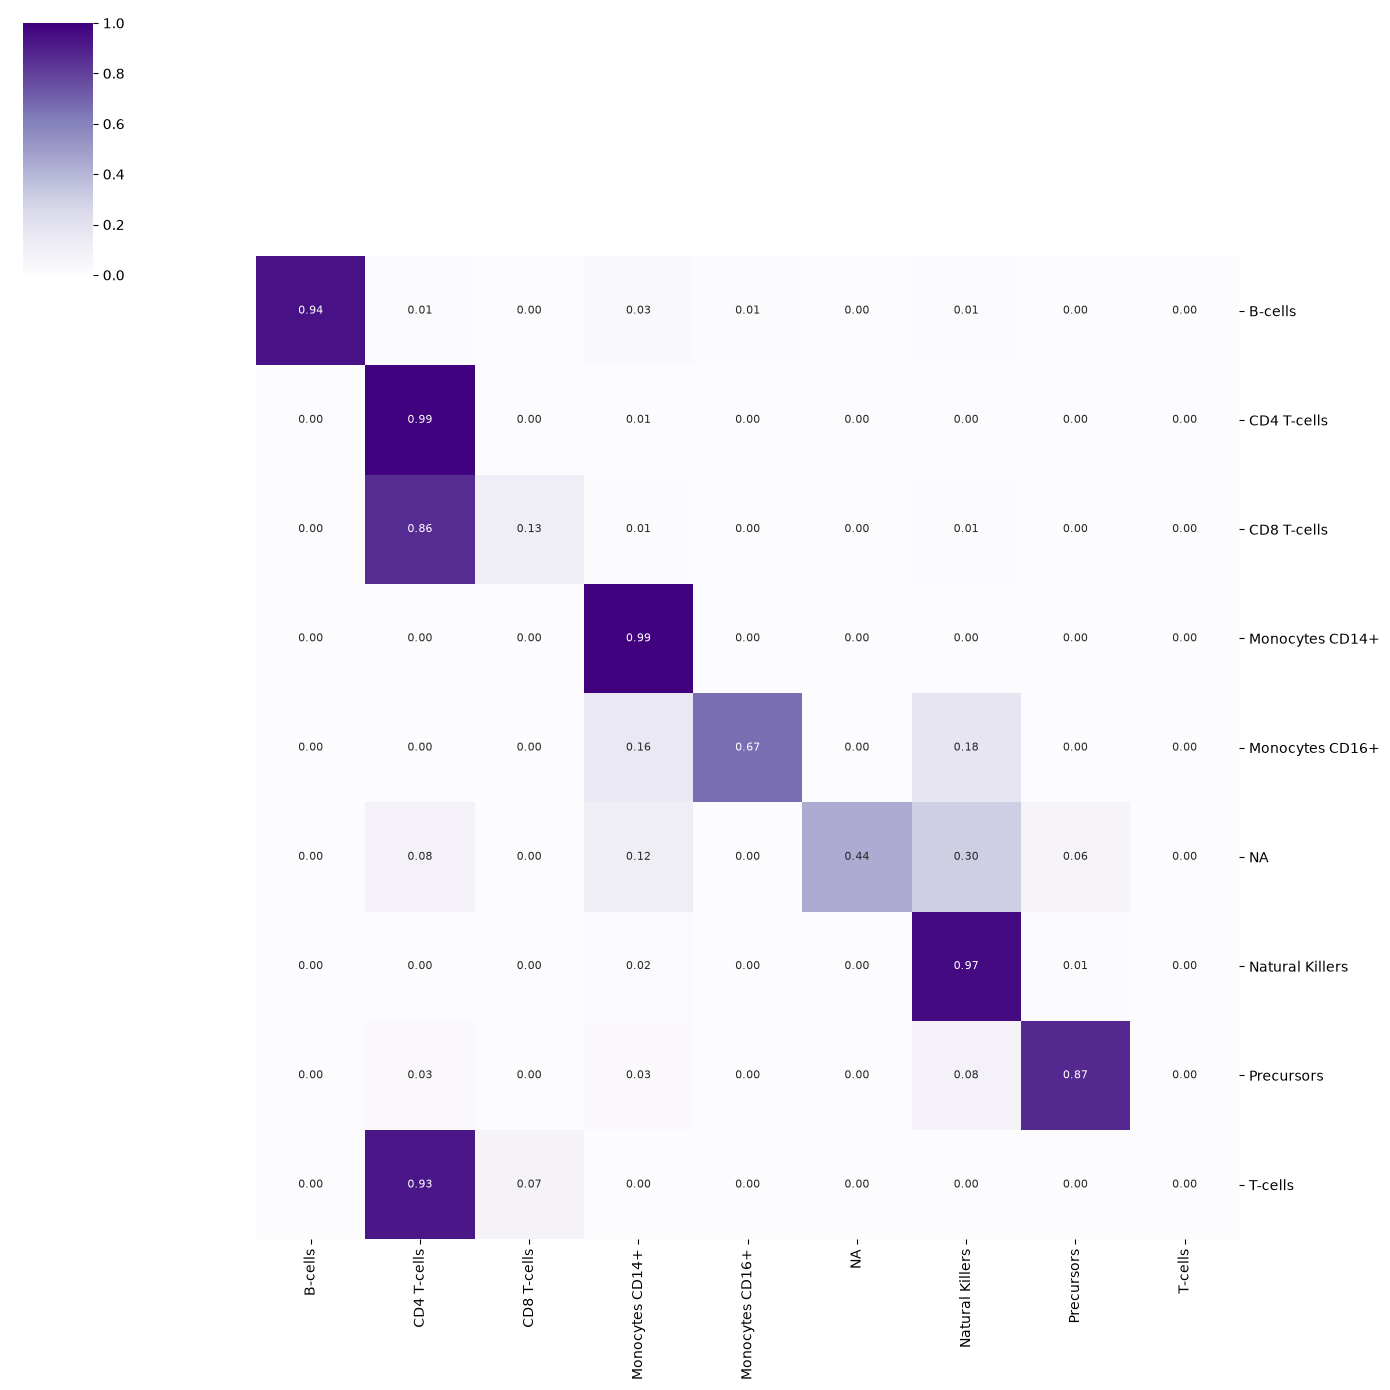

In [46]:
y_true = gt
y_pred = preds
cell_type_list = np.unique(y_true)
matrix = confusion_matrix(y_true, y_pred, labels=cell_type_list)
matrix = matrix.astype("float") / matrix.sum(axis=1)[:, np.newaxis]

df = pd.DataFrame(matrix, index=cell_type_list[:matrix.shape[0]], columns=cell_type_list[:matrix.shape[1]])

ax = sns.clustermap(df,  
                    cmap='Purples',
                    annot=True ,fmt=".2f", 
                    annot_kws={'size': 8}, 
                    vmin=0, 
                    vmax=1,
                    row_cluster=False, 
                    col_cluster=False, 
                    figsize=(14, 14))

Add the prediction in the adata concatenated so we can stop running this notebook forever!!

In [47]:
# Pad the list so its total length matches adata_concat
full_pred_list = list(preds) + ["Reference"] * (len(adata_concat) - len(preds))

# Assign to a new metadata column and convert to category
adata_concat.obs["predicted_cell_type"] = full_pred_list
adata_concat.obs["predicted_cell_type"] = adata_concat.obs["predicted_cell_type"].astype("category")

In [48]:
Counter(adata_concat.obs["predicted_cell_type"])

Counter({'Reference': 5476,
         'CD4 T-cells': 1091,
         'Monocytes CD14+': 739,
         'Natural Killers': 336,
         'B-cells': 98,
         'Precursors': 40,
         'Monocytes CD16+': 34,
         'NA': 25,
         'CD8 T-cells': 19})

In [49]:
adata_concat

AnnData object with n_obs × n_vars = 7858 × 17769
    obs: 'adt.discard', 'mito.discard', 'discard', 'species', 'celltype', 'markers', 'sum', 'detected', 'subsets_Mito_sum', 'subsets_Mito_detected', 'subsets_Mito_percent', 'altexps_scADT_sum', 'altexps_scADT_detected', 'altexps_scADT_percent', 'total', 'is_train', 'dataset', 'is_ref', 'celltype_masked', 'predicted_cell_type'
    var: 'gene_names', 'id_in_vocab'
    uns: 'neighbors', 'umap', 'is_ref_colors', 'celltype_masked_colors'
    obsm: 'X_scGPT', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [50]:
adata_concat.write("/projects/shared/intronic_bam/datasets/anndata/cb_scGPT_embeddings.h5ad", compression="gzip")